# Megaline: Análisis de Rentabilidad de Planes de Telecomunicaciones

## Descripción del Proyecto

Megaline, una empresa de telecomunicaciones, ofrece dos planes de prepago a sus clientes: Surf y Ultimate. El equipo comercial necesitaba determinar cuál de estos planes generaba mayores ingresos para optimizar la asignación de presupuesto de marketing y orientar futuras estrategias comerciales.

Como Analista de Datos, mi objetivo fue analizar el comportamiento de consumo de los clientes y evaluar el impacto financiero de cada plan mediante técnicas de limpieza, transformación, análisis exploratorio de datos y pruebas de hipótesis estadísticas.
__________________________________________________________________________________________________________________________________________________________________________________

## Objetivo de Negocio

Determinar cuál de los planes de Megaline genera mayores ingresos promedio para apoyar la toma de decisiones comerciales y de marketing.
__________________________________________________________________________________________________________________________________________________________________________________

## Datos Utilizados

El análisis se realizó utilizando información de 500 clientes de Megaline, incluyendo:
* Información de usuarios.
* Plan contratado.
* Llamadas realizadas.
* Mensajes enviados.
* Consumo de internet móvil.
* Tarifas y condiciones de cada plan.

## Inicialización

In [76]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
import math as mt
from matplotlib import pyplot as plt
from math import factorial
from scipy import stats as st

## Cargar datos

In [77]:
# Carga los archivos de datos en diferentes DataFrames
df_users = pd.read_csv(r"C:\Users\ricar\OneDrive\Escritorio\TRIPLETEN\Proyectos CV\Proyecto Megaline\CSV Megaline\megaline_users.csv", sep = ',')
df_calls = pd.read_csv(r"C:\Users\ricar\OneDrive\Escritorio\TRIPLETEN\Proyectos CV\Proyecto Megaline\CSV Megaline\megaline_calls.csv", sep = ',')
df_messages = pd.read_csv(r"C:\Users\ricar\OneDrive\Escritorio\TRIPLETEN\Proyectos CV\Proyecto Megaline\CSV Megaline\megaline_messages.csv", sep = ',')
df_internet = pd.read_csv(r"C:\Users\ricar\OneDrive\Escritorio\TRIPLETEN\Proyectos CV\Proyecto Megaline\CSV Megaline\megaline_internet.csv", sep = ',')
df_plans = pd.read_csv(r"C:\Users\ricar\OneDrive\Escritorio\TRIPLETEN\Proyectos CV\Proyecto Megaline\CSV Megaline\megaline_plans.csv", sep = ',')

##  Limpieza y Preparación de datos

Se realizaron tareas de preprocesamiento para asegurar la calidad de la información:
* Conversión de fechas a formato datetime.
* Corrección de tipos de datos.
* Tratamiento de valores ausentes.
* Creación de variables temporales (mes, año y día de la semana).
* Conversión de MB a GB para facilitar el análisis del consumo de internet.

In [78]:
# Inspecciona la estructura de cada DataFrame
df_users.info()
print('===================================================================')
df_calls.info()
print('===================================================================')
df_messages.info()
print('===================================================================')
df_internet.info()
print('===================================================================')
df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
<class 'pandas.core.frame.D

##### Comentario
Antes de realizar cualquier paso, debemos conocer los datos que se extraen de los DataFrame, utilizando el mótodo 'read_csv' y luego mostrando la información general con info().

## Tarifas

In [79]:
# Información general/resumida sobre el DataFrame de las tarifas
print('Descripción del DataFrame de las tarifas:')
print(df_plans.describe().round(2))

Descripción del DataFrame de las tarifas:
       messages_included  mb_per_month_included  minutes_included  \
count               2.00                   2.00              2.00   
mean              525.00               23040.00           1750.00   
std               671.75               10861.16           1767.77   
min                50.00               15360.00            500.00   
25%               287.50               19200.00           1125.00   
50%               525.00               23040.00           1750.00   
75%               762.50               26880.00           2375.00   
max              1000.00               30720.00           3000.00   

       usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
count             2.00        2.00             2.00            2.00  
mean             45.00        8.50             0.02            0.02  
std              35.36        2.12             0.01            0.01  
min              20.00        7.00             0.01     

In [80]:
# Visualizar las primeras filas del DataFrame de las tarifas
print(df_plans.head(2))

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


In [81]:
# Hay dos nombres de planes en el DataFrame Plans
print('===================================================================')
print('Nombres de planes actuales: ', df_plans['plan_name'].unique())
print('===================================================================')

Nombres de planes actuales:  ['surf' 'ultimate']


##### Comentario
En el DataFrame de Plans podemos ver que están presentes los dos planes de telecomunaciones Megaline, que son 'Surf' y 'Ultimate', siendo la primera con un precio más asequible. Existe una gran diferencia de precios en cuanto al costo de los planes. Sin embargo, en los recargos extra por uso de MB, minutos o mensajes de texto; se puede apreciar que en el plan 'Surf' es totalmente superior. Se verifica el tipo de texto de la información del DataFrame y está todo correcto. No hay existencia de datos ausentes, ya que con el uso de info() nos indica que no hay datos ausentes.

### Enriquecer y corrección de los datos

Es bastante importante la modificación de los nombres de las columnas sea descriptiva a los datos pertenecientes en ella. Por lo tanto, es necesario realizar ciertas modificaciones para una mejor interpretación de aquellos datos.

In [82]:
# Facilitar los nombres de las columnas y optimizar la información
df_plans.rename(columns = {'usd_per_gb':'cost_extra_gb'}, inplace = True)
df_plans.rename(columns = {'usd_per_minute':'cost_extra_minute'}, inplace = True)
df_plans.rename(columns = {'usd_per_message':'cost_extra_message'}, inplace = True)

df_plans['gb_per_month_included'] = df_plans['mb_per_month_included'] / 1000

df_plans.info()
print('===================================================================')
print(df_plans.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   cost_extra_gb          2 non-null      int64  
 5   cost_extra_message     2 non-null      float64
 6   cost_extra_minute      2 non-null      float64
 7   plan_name              2 non-null      object 
 8   gb_per_month_included  2 non-null      float64
dtypes: float64(3), int64(5), object(1)
memory usage: 276.0+ bytes
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  cost_extra_gb  cost_extra_message  cost_extra

## Usuarios/as

In [83]:
# Información general/resumida sobre el DataFrame de usuarios
print('Descripción del DataFrame de usuarios:')
print(df_users.describe().round(2))

Descripción del DataFrame de usuarios:
       user_id     age
count   500.00  500.00
mean   1249.50   45.49
std     144.48   16.97
min    1000.00   18.00
25%    1124.75   30.00
50%    1249.50   46.00
75%    1374.25   61.00
max    1499.00   75.00


In [84]:
# Muestra de datos para usuarios
print(df_users.head(10))

   user_id first_name  last_name  age                                    city  \
0     1000   Anamaria      Bauer   45   Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28         Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36    Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                           Tulsa, OK MSA   
4     1004    Leonila   Thompson   40         Seattle-Tacoma-Bellevue, WA MSA   
5     1005      Livia    Shields   31     Dallas-Fort Worth-Arlington, TX MSA   
6     1006     Jesusa   Bradford   73  San Francisco-Oakland-Berkeley, CA MSA   
7     1007    Eusebio      Welch   42           Grand Rapids-Kentwood, MI MSA   
8     1008      Emely    Hoffman   53       Orlando-Kissimmee-Sanford, FL MSA   
9     1009      Gerry     Little   19  San Jose-Sunnyvale-Santa Clara, CA MSA   

     reg_date      plan  churn_date  
0  2018-12-24  ultimate         NaN  
1  2018-08-13      surf         

##### Comentario
En cuanto al DataFrame Users podemos determinar que existen 500 clientes, en donde se enumeran del 1000 hasta el 1499, teniendo cada uno un 'user_id' único, lo que nos permite hacer una descripción del cliente (información personal). Además, vemos la presencia de datos ausentes, lo que nos podría llevar a errores al momento de realizar el análisis de este DtaFrame, por lo que es necesario realizar ajustes. Por otro lado, la columna de 'reg_date' está como 'object' (string), por lo que es necesario cambiar su tipo y transformarlo en 'datetime'.

### Corrección y modificación de datos

In [85]:
# Corrección de fecha del DataFrame Users -> columna = 'reg_date'
print('Corrección Dtype de "reg_date" del DataFrame Users')
print(df_users.head(10))
print('-------------------------------------------------------------------')
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'], format = '%Y-%m-%d')
print('Nuevo Dtype: ', df_users['reg_date'].dtypes)
print('-------------------------------------------------------------------')
print('Fecha más antigua: ', df_users['reg_date'].min())
print('Fecha más reciente: ', df_users['reg_date'].max())
print('===================================================================')

# DataFrame Users -> 'churn_date' -> 'NaN' a 'Cliente Activo'
df_users['churn_date'] = df_users['churn_date'].fillna('Cliente Activo')
print(df_users.head(10))

Corrección Dtype de "reg_date" del DataFrame Users
   user_id first_name  last_name  age                                    city  \
0     1000   Anamaria      Bauer   45   Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28         Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36    Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                           Tulsa, OK MSA   
4     1004    Leonila   Thompson   40         Seattle-Tacoma-Bellevue, WA MSA   
5     1005      Livia    Shields   31     Dallas-Fort Worth-Arlington, TX MSA   
6     1006     Jesusa   Bradford   73  San Francisco-Oakland-Berkeley, CA MSA   
7     1007    Eusebio      Welch   42           Grand Rapids-Kentwood, MI MSA   
8     1008      Emely    Hoffman   53       Orlando-Kissimmee-Sanford, FL MSA   
9     1009      Gerry     Little   19  San Jose-Sunnyvale-Santa Clara, CA MSA   

     reg_date      plan  churn_date  
0  2018-12-24  ulti

##### Comentarios
En la corrección de datos en el DataFrame Users es cambiar el Dtype de 'object' a 'datetime', utilizando el método **to_datetime()**. Por otro lado, se reemplazaron los valores ausentes NaN a 'Cliente Activo' en la columna 'churn_date', en donde se encuentra la fecha de término de contrato de los servicios de Telecomunicaciones Megaline.

### Enriquecer los datos

La divisón de fechas en años, meses y días de la semana son de extrema eficiencia, ya que te permite manipular de mejor manera los datos presentes en el DataFrame y realizar un manejo óptimo de la información.

In [86]:
# Dividir las fechas en culumnas de años, meses, días
df_users['year'] = df_users['reg_date'].dt.year
df_users['month'] = df_users['reg_date'].dt.month
df_users['day_of_week'] = df_users['reg_date'].dt.dayofweek

df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      500 non-null    int64         
 1   first_name   500 non-null    object        
 2   last_name    500 non-null    object        
 3   age          500 non-null    int64         
 4   city         500 non-null    object        
 5   reg_date     500 non-null    datetime64[ns]
 6   plan         500 non-null    object        
 7   churn_date   500 non-null    object        
 8   year         500 non-null    int32         
 9   month        500 non-null    int32         
 10  day_of_week  500 non-null    int32         
dtypes: datetime64[ns](1), int32(3), int64(2), object(5)
memory usage: 37.2+ KB


## Llamadas

In [87]:
# Información general/resumida sobre el DataFrame de las llamadas
print('Descripción del DataFrame de las llamadas:')
print(df_calls.describe().round(2))

Descripción del DataFrame de las llamadas:
         user_id   duration
count  137735.00  137735.00
mean     1247.66       6.75
std       139.42       5.84
min      1000.00       0.00
25%      1128.00       1.29
50%      1247.00       5.98
75%      1365.00      10.69
max      1499.00      37.60


In [88]:
# Muestra de datos para las llamadas
print(df_calls.head(10))

         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22
5  1000_388     1000  2018-12-31      2.20
6  1000_510     1000  2018-12-27      5.75
7  1000_521     1000  2018-12-28     14.18
8  1000_530     1000  2018-12-28      5.77
9  1000_544     1000  2018-12-26      4.40


### Corrección de datos

Para la corrección de datos del DatFrame, nuevamente debemos hacer el mismo procedimiento para cambiar el Dtype de 'object' a 'datetime'. Sería la única corrección a considerar para la optimización del DataFrame.

In [89]:
# Corrección de fecha del DataFrame Calls -> columna = 'call_date'
print('Corrección Dtype de "call_date" del DataFrame Calls')
print(df_calls.head(10))
print('-------------------------------------------------------------------')
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'], format = '%Y-%m-%d')
print('Nuevo Dtype: ', df_calls['call_date'].dtypes)
print('-------------------------------------------------------------------')
print('Fecha más antigua: ', df_calls['call_date'].min())
print('Fecha más reciente: ', df_calls['call_date'].max())
print('===================================================================')

Corrección Dtype de "call_date" del DataFrame Calls
         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22
5  1000_388     1000  2018-12-31      2.20
6  1000_510     1000  2018-12-27      5.75
7  1000_521     1000  2018-12-28     14.18
8  1000_530     1000  2018-12-28      5.77
9  1000_544     1000  2018-12-26      4.40
-------------------------------------------------------------------
Nuevo Dtype:  datetime64[ns]
-------------------------------------------------------------------
Fecha más antigua:  2018-01-15 00:00:00
Fecha más reciente:  2018-12-31 00:00:00


### Enriquecer los datos

Para enriquecer el análisis de datos, es necesario que se distingan los días de la semana, meses y años de la columna 'call_date', con el propósito de después cruzar la información con los otros DataFrames en estudio. Es decir, como se mencionó anteriormente, es eficiente realizar este tipo de acciones con tal de optimizar la manipulación de datos y obtener la información deseada de forma eficiente.

In [90]:
# Dividir las fechas en culumnas de años, meses, días
df_calls['year'] = df_calls['call_date'].dt.year
df_calls['month'] = df_calls['call_date'].dt.month
df_calls['day_of_week'] = df_calls['call_date'].dt.dayofweek

df_calls.info()
print('===================================================================')

print(df_calls.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id           137735 non-null  object        
 1   user_id      137735 non-null  int64         
 2   call_date    137735 non-null  datetime64[ns]
 3   duration     137735 non-null  float64       
 4   year         137735 non-null  int32         
 5   month        137735 non-null  int32         
 6   day_of_week  137735 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(3), int64(1), object(1)
memory usage: 5.8+ MB
         id  user_id  call_date  duration  year  month  day_of_week
0   1000_93     1000 2018-12-27      8.52  2018     12            3
1  1000_145     1000 2018-12-27     13.66  2018     12            3
2  1000_247     1000 2018-12-27     14.48  2018     12            3
3  1000_309     1000 2018-12-28      5.76  2018     12            4
4  1000_3

## Mensajes

In [91]:
# Información general/resumida sobre el DataFrame de los mensajes
print('Descripción del DataFrame de los mensajes:')
print(df_messages.describe().round(2))

Descripción del DataFrame de los mensajes:
        user_id
count  76051.00
mean    1245.97
std      139.84
min     1000.00
25%     1123.00
50%     1251.00
75%     1362.00
max     1497.00


In [92]:
# Muestra de datos para los mensajes
print(df_messages.head(10))

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26
5  1000_346     1000   2018-12-29
6  1000_386     1000   2018-12-30
7  1000_413     1000   2018-12-31
8  1000_502     1000   2018-12-27
9  1000_525     1000   2018-12-28


##### Comentario
En el DataFrame Messages tenemos 3 columnas que nos describe el usuario, el código de los mensajes y la fecha del envío del mensaje. Podemos ver que el Dtype está en 'object' y es una obligación transformarlo a 'datetime'.

### Corrección de datos

In [93]:
# Corrección de fecha del DataFrame Messages -> columna = 'message_date'
print('Corrección Dtype de "message_date" del DataFrame Messages')
print(df_messages.head(10))
print('-------------------------------------------------------------------')
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'], format = '%Y-%m-%d')
print('Nuevo Dtype: ', df_messages['message_date'].dtypes)
print('-------------------------------------------------------------------')
print('Fecha más antigua: ', df_messages['message_date'].min())
print('Fecha más reciente: ', df_messages['message_date'].max())
print('===================================================================')

Corrección Dtype de "message_date" del DataFrame Messages
         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26
5  1000_346     1000   2018-12-29
6  1000_386     1000   2018-12-30
7  1000_413     1000   2018-12-31
8  1000_502     1000   2018-12-27
9  1000_525     1000   2018-12-28
-------------------------------------------------------------------


Nuevo Dtype:  datetime64[ns]
-------------------------------------------------------------------
Fecha más antigua:  2018-01-15 00:00:00
Fecha más reciente:  2018-12-31 00:00:00


### Enriquecer los datos

In [94]:
# Dividir las fechas en culumnas de años, meses, días
df_messages['year'] = df_messages['message_date'].dt.year
df_messages['month'] = df_messages['message_date'].dt.month
df_messages['day_of_week'] = df_messages['message_date'].dt.dayofweek
print('-------------------------------------------------------------------')
df_messages.info()
print('===================================================================')

-------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   year          76051 non-null  int32         
 4   month         76051 non-null  int32         
 5   day_of_week   76051 non-null  int32         
dtypes: datetime64[ns](1), int32(3), int64(1), object(1)
memory usage: 2.6+ MB


## Internet

In [95]:
# Imprime la información general/resumida sobre el DataFrame de internet
print('Descripción del DataFrame de internet:')
print(df_internet.describe().round(2))

Descripción del DataFrame de internet:
         user_id    mb_used
count  104825.00  104825.00
mean     1242.50     366.71
std       142.05     277.17
min      1000.00       0.00
25%      1122.00     136.08
50%      1236.00     343.98
75%      1367.00     554.61
max      1499.00    1693.47


In [96]:
# Muestra de datos para el tráfico de internet
print(df_internet.head(10))

         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22
5    1001_0     1001   2018-08-24   284.68
6    1001_3     1001   2018-12-09   656.04
7    1001_4     1001   2018-11-04    16.97
8   1001_10     1001   2018-11-27   135.18
9   1001_15     1001   2018-12-13   761.92


### Corregir los datos

In [97]:
# Corrección de fecha del DataFrame Internet -> columna = 'session_date'
print('Corrección Dtype de "session_date" del DataFrame Internet')
print(df_internet.head(10))
print('-------------------------------------------------------------------')
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'], format = '%Y-%m-%d')
print('Nuevo Dtype: ', df_internet['session_date'].dtypes)
print('-------------------------------------------------------------------')
print('Fecha más antigua: ', df_internet['session_date'].min())
print('Fecha más reciente: ', df_internet['session_date'].max())
print('===================================================================')

Corrección Dtype de "session_date" del DataFrame Internet
         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22
5    1001_0     1001   2018-08-24   284.68
6    1001_3     1001   2018-12-09   656.04
7    1001_4     1001   2018-11-04    16.97
8   1001_10     1001   2018-11-27   135.18
9   1001_15     1001   2018-12-13   761.92
-------------------------------------------------------------------
Nuevo Dtype:  datetime64[ns]
-------------------------------------------------------------------
Fecha más antigua:  2018-01-15 00:00:00
Fecha más reciente:  2018-12-31 00:00:00


### Enriquecer los datos

En el DataFrame Internet hay una gran cantidad de datos interesantes a considerar para su posterior análisis y tomar decisiones (más si estamos en una sociedad ligada a las Redes Sociales). Podemos extraer que tenemos 4 columnas, por lo que es importante destacar la columna 'mb_used', siendo de información que nos puede formar un poco de ruido. Por lo tanto, es necesario realizar una conversión de megabytes a gigabytes.

In [98]:
# Crear una nueva columna -> 'gb_used'
df_internet['gb_used'] = df_internet['mb_used'] / 1000

# Dividir las fechas en culumnas de años, meses, días
df_internet['year'] = df_internet['session_date'].dt.year
df_internet['month'] = df_internet['session_date'].dt.month
df_internet['day_of_week'] = df_internet['session_date'].dt.dayofweek

df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   gb_used       104825 non-null  float64       
 5   year          104825 non-null  int32         
 6   month         104825 non-null  int32         
 7   day_of_week   104825 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(1), object(1)
memory usage: 5.2+ MB


## Estudiar las condiciones de las tarifas

Las condiciones de las tarifas de los dos planes de la empresa de telecomunicaciones Megaline son las siguientes:

In [99]:
# Condiciones de la tarifa
print('===================================================================')
print('Tarifa:', df_plans['plan_name'][0])
print('Valor Mensual:$', df_plans['usd_monthly_pay'][0])
print('-> Minutos incluidos:', df_plans['minutes_included'][0].round(0))
print('-> SMS incluidos:', df_plans['messages_included'][0].round(0))
print('-> GB incluidos:', df_plans['gb_per_month_included'][0].round(2))
print('* Tarifas por exceso:')
print('-> Minuto extra: $', df_plans['cost_extra_minute'][0].round(2))
print('-> SMS extra: $', df_plans['cost_extra_message'][0].round(2))
print('-> GB extra: $', df_plans['cost_extra_gb'][0].round(2))
print('===================================================================')

print('Tarifa:', df_plans['plan_name'][1])
print('Valor Mensual:$', df_plans['usd_monthly_pay'][1])
print('-> Minutos incluidos:', df_plans['minutes_included'][1].round(0))
print('-> SMS incluidos:', df_plans['messages_included'][1].round(0))
print('-> GB incluidos:', df_plans['gb_per_month_included'][1].round(2))
print('* Tarifas por exceso:')
print('-> Minuto extra: $', df_plans['cost_extra_minute'][1].round(2))
print('-> SMS extra: $', df_plans['cost_extra_message'][1].round(2))
print('-> GB extra: $', df_plans['cost_extra_gb'][1].round(2))
print('===================================================================')

Tarifa: surf
Valor Mensual:$ 20
-> Minutos incluidos: 500
-> SMS incluidos: 50
-> GB incluidos: 15.36
* Tarifas por exceso:
-> Minuto extra: $ 0.03
-> SMS extra: $ 0.03
-> GB extra: $ 10
Tarifa: ultimate
Valor Mensual:$ 70
-> Minutos incluidos: 3000
-> SMS incluidos: 1000
-> GB incluidos: 30.72
* Tarifas por exceso:
-> Minuto extra: $ 0.01
-> SMS extra: $ 0.01
-> GB extra: $ 7


## Construcción de Métricas de consumo

Se calcularon indicadores mensuales por usuario:
* Cantidad de llamadas realizadas.
* Minutos consumidos.
* Cantidad de mensajes enviados.
* Tráfico de internet utilizado.
* Excedentes de consumo.
* Ingreso mensual generado por cada cliente.

### Agregar datos por usuario

Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior. Por lo tanto, debemos agrupar los 'user_id' y sus respectivos meses de consumo.

In [100]:
# Número de llamadas hechas por cada usuario al mes.
print('===================================================================')
calls_per_user = df_calls.groupby('user_id')['id'].count()
print(calls_per_user)
print('===================================================================')
# Tabla de llamadas por usuario por mes
calls_per_user_month = df_calls.pivot_table(index = 'user_id',
                                            columns = 'month',
                                            values = 'id',
                                            aggfunc = 'count')
calls_per_user_month.fillna(0, inplace = True)
print(calls_per_user_month)
print('===================================================================')

user_id
1000     16
1001    261
1002    113
1003    149
1004    370
       ... 
1495    253
1496    195
1497     54
1498    451
1499    204
Name: id, Length: 481, dtype: int64


month     1     2     3     4     5     6     7     8     9     10    11  \
user_id                                                                    
1000     0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
1001     0.0   0.0   0.0   0.0   0.0   0.0   0.0  27.0  49.0  65.0  64.0   
1002     0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  11.0  55.0   
1003     0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
1004     0.0   0.0   0.0   0.0  21.0  44.0  49.0  49.0  42.0  61.0  54.0   
...      ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   
1495     0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  52.0  75.0  61.0   
1496     0.0   0.0   0.0   0.0   0.0   0.0   0.0  18.0  52.0  46.0  39.0   
1497     0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
1498     0.0  37.0  37.0  47.0  35.0  37.0  43.0  44.0  45.0  46.0  41.0   
1499     0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  41.0  53.0  45.0   

month      

In [101]:
# Cantidad de minutos usados por cada usuario al mes.
print('===================================================================')
minutes_per_user = df_calls.groupby('user_id')['duration'].sum()
print(minutes_per_user)
print('===================================================================')
# Tabla de minutos por usuario por mes
minutes_per_user_month = df_calls.pivot_table(index = 'user_id',
                                              columns = 'month',
                                              values = 'duration',
                                              aggfunc = 'sum')
minutes_per_user_month.fillna(0, inplace = True)
print(minutes_per_user_month)
print('===================================================================')

user_id
1000     116.83
1001    1640.46
1002     777.13
1003    1041.00
1004    2618.95
         ...   
1495    1666.41
1496    1376.21
1497     276.53
1498    3029.97
1499    1450.31
Name: duration, Length: 481, dtype: float64


month     1       2       3       4       5       6       7       8       9   \
user_id                                                                        
1000     0.0    0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00   
1001     0.0    0.00    0.00    0.00    0.00    0.00    0.00  171.14  297.69   
1002     0.0    0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00   
1003     0.0    0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00   
1004     0.0    0.00    0.00    0.00  181.58  261.32  358.45  334.86  284.60   
...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
1495     0.0    0.00    0.00    0.00    0.00    0.00    0.00    0.00  283.46   
1496     0.0    0.00    0.00    0.00    0.00    0.00    0.00  114.62  389.94   
1497     0.0    0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00   
1498     0.0  231.87  247.72  344.18  275.13  225.57  304.49  244.57  344.62   
1499     0.0    0.00    0.00    0.00    

In [102]:
# Número de mensajes enviados por cada usuario al mes.
print('===================================================================')
messages_per_user = df_messages.groupby('user_id')['id'].count()
print(messages_per_user)
print('===================================================================')
# Tabla de SMS por usuario por mes
messages_per_user_month = df_messages.pivot_table(index = 'user_id',
                                                  columns = 'month',
                                                  values = 'id',
                                                  aggfunc = 'count')
messages_per_user_month.fillna(0, inplace = True)
print(messages_per_user_month)
print('===================================================================')

user_id
1000     11
1001    207
1002     88
1003     50
1004    177
       ... 
1491    409
1492    108
1494    174
1496     65
1497     50
Name: id, Length: 402, dtype: int64
month     1    2    3    4     5     6     7     8     9     10    11    12
user_id                                                                    
1000     0.0  0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  11.0
1001     0.0  0.0  0.0  0.0   0.0   0.0   0.0  30.0  44.0  53.0  36.0  44.0
1002     0.0  0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0  15.0  32.0  41.0
1003     0.0  0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  50.0
1004     0.0  0.0  0.0  0.0   7.0  18.0  26.0  25.0  21.0  24.0  25.0  31.0
...      ...  ...  ...  ...   ...   ...   ...   ...   ...   ...   ...   ...
1491     0.0  0.0  0.0  6.0  45.0  54.0  64.0  50.0  50.0  51.0  46.0  43.0
1492     0.0  0.0  0.0  0.0   0.0   0.0   0.0   0.0  11.0  29.0  31.0  37.0
1494     0.0  0.0  0.0  0.0   0.0   0.0  20.0  27.0  21.0  38.0 

In [103]:
# Volumen del tráfico de Internet usado por cada usuario al mes.
print('===================================================================')
mb_per_user = df_internet.groupby('user_id')['mb_used'].sum()
print(mb_per_user)
print('===================================================================')
gb_per_user = df_internet.groupby('user_id')['gb_used'].sum().round(2)
print(gb_per_user)
print('===================================================================')
# Tabla de GB por usuario por mes
gb_per_user_month = df_internet.pivot_table(index = 'user_id',
                                            columns = 'month',
                                            values = 'gb_used',
                                            aggfunc = 'sum')
gb_per_user_month.fillna(0, inplace = True)
print(gb_per_user_month.round(2))
print('===================================================================')

user_id
1000      1901.47
1001     80437.94
1002     40293.33
1003     27044.14
1004    156352.81
          ...    
1495     98890.96
1496     64268.64
1497     11106.55
1498    227525.13
1499     71350.23
Name: mb_used, Length: 489, dtype: float64
user_id
1000      1.90
1001     80.44
1002     40.29
1003     27.04
1004    156.35
         ...  
1495     98.89
1496     64.27
1497     11.11
1498    227.53
1499     71.35
Name: gb_used, Length: 489, dtype: float64
month     1      2      3      4      5      6      7      8      9      10  \
user_id                                                                       
1000     0.0   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   
1001     0.0   0.00   0.00   0.00   0.00   0.00   0.00   6.92  13.31  22.33   
1002     0.0   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   6.55   
1003     0.0   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   
1004     0.0   0.00   0.00   0.00   6.55  20.67  24.52  27.98

##### Comentario
Como podemos ver en la tabla de pivote que contiene el número de llamadas por cada usuario al mes, podemos ver destacar que durante los primeros meses (Enero especialmente) se puede apreciar que la gran mayoría de clientes no tuvo un gran consumo de llamadas telefónicas. Lo mismo pasa con los mensajes y el tráfico de internet, teniendo un comporameitno parecido. Esto se debe a que se fueron incorporando nuevos clientes a la empresa Megaline.

Para un mejor análisis, es necesario cruzar la información antes evaluada para determinar los insight de nuestros clientes. Entonces, vamos a formar un DataFrame que contenga los datos necesarios para la toma de decisiones.

In [104]:
# Fusión los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
print('===================================================================')
# Serie a DataFrame
df_it1 = df_calls.groupby(['user_id','month'])['id'].count().reset_index()
df_it1.rename(columns = {'id' : 'calls_count'}, inplace = True)

df_calls['duration'] = np.ceil(df_calls['duration'])
df_it2 = df_calls.groupby(['user_id','month'])['duration'].sum().reset_index()
df_it2.rename(columns = {'duration' : 'minutes_sum'}, inplace = True)

df_it3 = df_messages.groupby(['user_id', 'month'])['id'].count().reset_index()
df_it3.rename(columns = {'id' : 'messages_count'}, inplace = True)

df_it4 = df_internet.groupby(['user_id', 'month'])['gb_used'].sum().round(2).reset_index()
df_it4['gb_used'] = np.ceil(df_it4['gb_used'])

# Creación del DataFrame solicitado
df_fin1 = df_it1.merge(df_it2, on = ['user_id', 'month'], how = 'outer')
df_fin2 = df_fin1.merge(df_it3, on = ['user_id', 'month'], how = 'outer')
df_total = df_fin2.merge(df_it4, on = ['user_id', 'month'], how = 'outer')

df_total.fillna(0, inplace = True)

print(df_total)
print('===================================================================')

      user_id  month  calls_count  minutes_sum  messages_count  gb_used
0        1000     12         16.0        124.0            11.0      2.0
1        1001      8         27.0        182.0            30.0      7.0
2        1001      9         49.0        315.0            44.0     14.0
3        1001     10         65.0        393.0            53.0     23.0
4        1001     11         64.0        426.0            36.0     19.0
...       ...    ...          ...          ...             ...      ...
2288     1498     12         39.0        339.0             0.0     24.0
2289     1499      9         41.0        346.0             0.0     13.0
2290     1499     10         53.0        385.0             0.0     20.0
2291     1499     11         45.0        308.0             0.0     17.0
2292     1499     12         65.0        496.0             0.0     23.0

[2293 rows x 6 columns]


In [105]:
# Añadir la información de la tarifa
print('===================================================================')
df_total_user = df_total.merge(df_users, on = 'user_id', how = 'left')
print(df_total_user)
print('===================================================================')
df_total_user.rename(columns = {'plan' : 'plan_name'}, inplace = True)
df_total_fee = df_total_user.merge(df_plans, on = 'plan_name', how = 'left')
print(df_total_fee)
print('===================================================================')

      user_id  month_x  calls_count  minutes_sum  messages_count  gb_used  \
0        1000       12         16.0        124.0            11.0      2.0   
1        1001        8         27.0        182.0            30.0      7.0   
2        1001        9         49.0        315.0            44.0     14.0   
3        1001       10         65.0        393.0            53.0     23.0   
4        1001       11         64.0        426.0            36.0     19.0   
...       ...      ...          ...          ...             ...      ...   
2288     1498       12         39.0        339.0             0.0     24.0   
2289     1499        9         41.0        346.0             0.0     13.0   
2290     1499       10         53.0        385.0             0.0     20.0   
2291     1499       11         45.0        308.0             0.0     17.0   
2292     1499       12         65.0        496.0             0.0     23.0   

     first_name   last_name  age                                       city

##### Comentario
Como ya tenemos la información de nuestros Planes de Surf y Ultimate, en cuanto a la frecuencia de uso de llamadas, mensajes y tráfico por internet; en conjunto a los meses del año analizado, para establecer y determinar el comportamiento de nuestros clientes. Sin embargo, debemos calcular nuestros ingresos mensuales por usuario y por periodo determinado. Esto es de suma importancia, ya que podemos saber cuánto consume el usuario, si es que necestó más minutos, mensajes o gigabytes extra en su plan actual. Esta información nos podrá ayudar a determinar nuevos planes con tarifas que puedan aumentar la satisfacción de los clientes y cumplir las expectativas, tanto del usuario como las de la empresa de telecomunicaciones.

In [106]:
# Ingreso mensual para cada usuario
print('===================================================================')

df_total_fee['income_extra_minutes'] = np.where(
    df_total_fee['minutes_sum'] > df_total_fee['minutes_included'],
    (df_total_fee['minutes_sum'] - df_total_fee['minutes_included']) * df_total_fee['cost_extra_minute'],
    0
)

df_total_fee['income_extra_messages'] = np.where(
    df_total_fee['messages_count'] > df_total_fee['messages_included'],
    (df_total_fee['messages_count'] - df_total_fee['messages_included']) * df_total_fee['cost_extra_message'],
    0
)

df_total_fee['income_extra_gb'] = np.where(
    df_total_fee['gb_used'] > df_total_fee['gb_per_month_included'],
    (df_total_fee['gb_used'] - df_total_fee['gb_per_month_included']) * df_total_fee['cost_extra_gb'],
    0
)

# Ingresos usuario mensuales
df_total_fee['income_month_plan'] = df_total_fee['usd_monthly_pay'] + df_total_fee['income_extra_minutes'] + df_total_fee['income_extra_messages'] + df_total_fee['income_extra_gb']

# Veamos el DataFrame
print(df_total_fee.head(20))
print('===================================================================')

    user_id  month_x  calls_count  minutes_sum  messages_count  gb_used  \
0      1000       12         16.0        124.0            11.0      2.0   
1      1001        8         27.0        182.0            30.0      7.0   
2      1001        9         49.0        315.0            44.0     14.0   
3      1001       10         65.0        393.0            53.0     23.0   
4      1001       11         64.0        426.0            36.0     19.0   
5      1001       12         56.0        412.0            44.0     20.0   
6      1002       10         11.0         59.0            15.0      7.0   
7      1002       11         55.0        386.0            32.0     20.0   
8      1002       12         47.0        384.0            41.0     15.0   
9      1003       12        149.0       1104.0            50.0     28.0   
10     1004        5         21.0        193.0             7.0      7.0   
11     1004        6         44.0        275.0            18.0     21.0   
12     1004        7     

## Estudio del comportamiento de usuario - Análisis Exploratorio de Datos (EDA)

Para la comprensión de la información antes analizada, es necesario y óptimo crear gráficos para dar una lectura correcta a los datos. Es más beneficioso utilizar estas herramientas para poder identificar comportamientos que sean 'atípicos' de nuestros clientes y buscar una explicación a éste.
Además, nos puede facilitar la toma de decisiones y saber qué plan nos da mayor utilidad (no quiere decir que el otro plan sea malo, sino que podría tener ciertas modificaciones para aumentar la satisfacción del cliente).

### Llamadas

plan_name        surf    ultimate
month_x                          
1          203.000000  193.500000
2          297.000000  403.142857
3          330.000000  304.250000
4          351.540000  336.857143
5          399.584416  406.241379
6          431.298969  370.957447
7          449.983471  427.067797
8          410.111111  421.436620
9          414.226804  437.511628
10         429.729958  450.735849
11         423.325088  445.196850
12         473.836478  459.099338


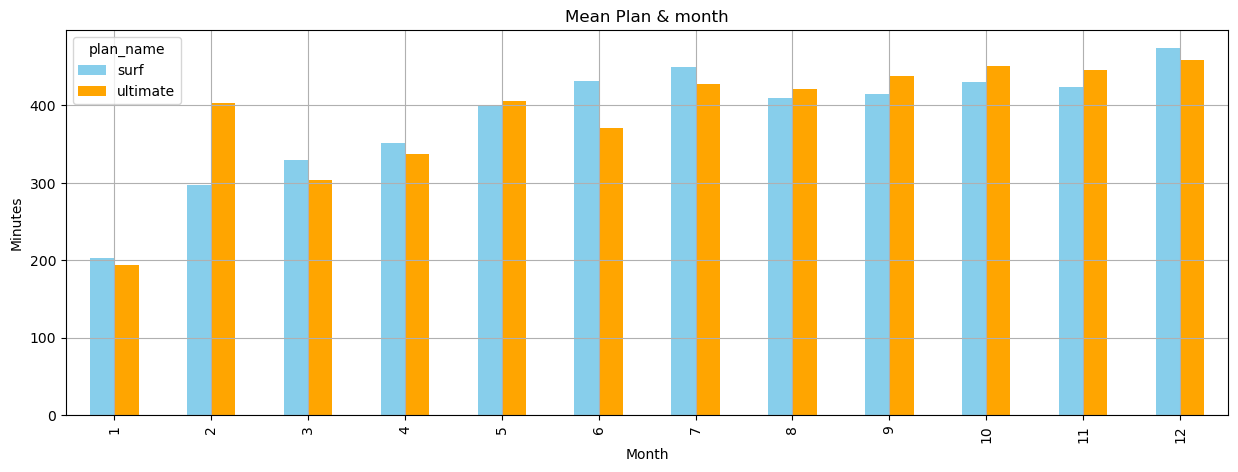

In [107]:
# Comparación de la duración promedio de llamadas por cada plan y por cada mes. 
duration_mean_plan_month = df_total_fee.groupby(['month_x','plan_name'])['minutes_sum'].mean().unstack()
print(duration_mean_plan_month)
print('===================================================================')

duration_mean_plan_month.plot(xlabel = 'Month',
                              ylabel = 'Minutes',
                              title = 'Mean Plan & month',
                              kind = 'bar',
                              color = ['skyblue', 'orange'],
                              legend = 'Plan',
                              figsize = (15,5),
                              grid =True)
plt.show()

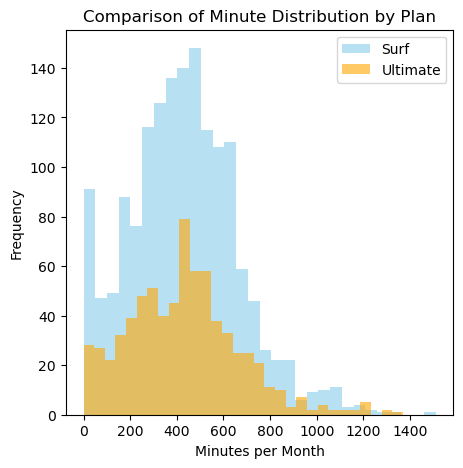

N° Users Surf: 339
N° Users Ultimate: 161


In [108]:
# Comparación del número de minutos mensuales que necesitan los usuarios de cada plan.
print('===================================================================')
surf_minutes = df_total_fee[df_total_fee['plan_name'] == 'surf']['minutes_sum']
ultimate_minutes = df_total_fee[df_total_fee['plan_name'] == 'ultimate']['minutes_sum']

# Juntar los DataFrame
surf_minutes.plot(kind = 'hist',
                  bins = 30,
                  alpha = 0.6,
                  color = 'skyblue',
                  figsize = (5,5),
                  ylabel = 'Users',
                  title = 'Comparison of Minute Distribution by Plan')
ultimate_minutes.plot(kind = 'hist',
                      bins = 30,
                      alpha = 0.6,
                      color = 'orange')
plt.xlabel('Minutes per Month')
plt.legend(['Surf','Ultimate'])
plt.show()
print('===================================================================')
plan_surf = len(df_users[df_users['plan'] == 'surf'])
plan_ultimate = len(df_users[df_users['plan'] == 'ultimate'])
print('N° Users Surf:', plan_surf)
print('N° Users Ultimate:', plan_ultimate)
print('===================================================================')

In [112]:
# Media y Varianza de la duración mensual de llamadas.

# Ya poseo los planes diferenciados (Surf & Ultimate) respecto a su duración de llamadas
# Surf -> Media y Varianza
media_surf = surf_minutes.mean().round(2)
var_surf = surf_minutes.var()
desv_surf = np.sqrt(var_surf).round(2)
print('Los datos del Plan Surf:')
print('-> Media:', media_surf)
print('-> Varianza:', var_surf)
print('-> Sigma:', desv_surf)
print('===================================================================')

# Ultimate -> Media y Varianza
media_ultimate = ultimate_minutes.mean().round(2)
var_ultimate = ultimate_minutes.var()
desv_ultimate = np.sqrt(var_ultimate).round(2)
print('Los datos del Plan Ultimate:')
print('-> Media:', media_ultimate)
print('-> Varianza:', var_ultimate)
print('-> Sigma:', desv_ultimate)

Los datos del Plan Surf:
-> Media: 428.75
-> Varianza: 54968.27946065032
-> Sigma: 234.45
Los datos del Plan Ultimate:
-> Media: 430.45
-> Varianza: 57844.4648122392
-> Sigma: 240.51


C:\Users\ricar\AppData\Local\Temp\ipykernel_20344\1898158255.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot,


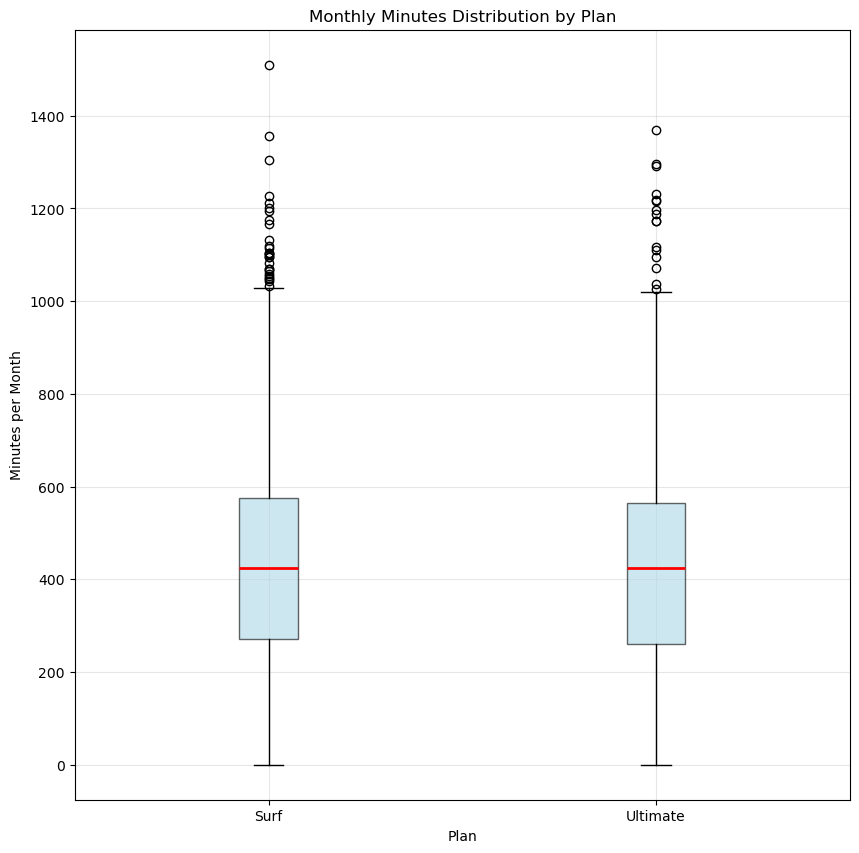

In [114]:
# Diagrama de caja para visualización de la distribución de la duración mensual de llamadas
surf_minutes = df_total_fee[df_total_fee['plan_name'] == 'surf']['minutes_sum']
ultimate_minutes = df_total_fee[df_total_fee['plan_name'] == 'ultimate']['minutes_sum']

data_to_plot = [surf_minutes, ultimate_minutes]
plt.figure(figsize = (10,10))

# Creación del Diagrama de Caja
plt.boxplot(data_to_plot, 
            labels = ['Surf', 'Ultimate'],
            patch_artist = True,
            boxprops = dict(facecolor = 'lightblue', alpha = 0.6),
            medianprops = dict(color = 'red', linewidth = 2))
plt.xlabel('Plan')
plt.ylabel('Minutes per Month')
plt.title('Monthly Minutes Distribution by Plan')
plt.grid(True, alpha = 0.3)
plt.show()

##### Comentario
Respecto al gráfico de la duración (en minutos) promedio de llamadas por plan y mes, nos indica que el mes de Febrero se obtuvo una gran diferencia (cercano a 100 minutos promedio) del Plan 'Ultimate' con 'Surf'. Esto se puede dar por el hecho de que es temporada de vacaciones y la gente necesita comunicarse más con el círculo más cercano de los usuarios.
Respecto al gráfico de Comparación del número de minutos totales por usuario por mes, hay un mayor uso de personas y períodos donde se centra un mayor consumo de minutos entre el rango de 200 - 600 minutos (en ambos planes). Esto nos dice que la media de llamadas está en ese rango. Además, existe un mayor onsumo por parte de los usuarios plan 'Surf', ya que son más clientes que tienen contratado ese plan.
En cuanto al Diagrama de caja, nos facilita entender la tendencia de que la mediana de ambos planes se encuentra en los 400 minutos por usuario y mes. Lo que es llamativo, es que existe un gran número de usuarios que tiene el plan 'Surf' y hace un uso por sobre del limite del plan, lo que hace que pague el cliente por minutos extra, siendo una oportunidad de negocio.

### Mensajes

In [116]:
# Comparación del número de mensajes que tienden a enviar cada mes los usuarios de cada plan
num_sms_plan_month = df_total_fee.groupby(['month_x','plan_name'])['messages_count'].sum().unstack()
print(num_sms_plan_month)
print('===================================================================')

# Comparación del promedio de mensajes
mean_sms_plan_month = df_total_fee.groupby(['month_x','plan_name'])['messages_count'].mean().unstack()
print(mean_sms_plan_month.round(2))

plan_name     surf  ultimate
month_x                     
1             21.0      62.0
2            108.0     151.0
3            351.0     243.0
4            870.0     463.0
5           1849.0     931.0
6           2454.0    1379.0
7           3271.0    1937.0
8           4662.0    2732.0
9           5968.0    3259.0
10          8020.0    4181.0
11          9165.0    4903.0
12         12275.0    6796.0
plan_name   surf  ultimate
month_x                   
1          10.50     15.50
2          12.00     21.57
3          15.26     20.25
4          17.40     22.05
5          24.01     32.10
6          25.30     29.34
7          27.03     32.83
8          28.78     38.48
9          30.76     37.90
10         33.84     39.44
11         32.39     38.61
12         38.60     45.01


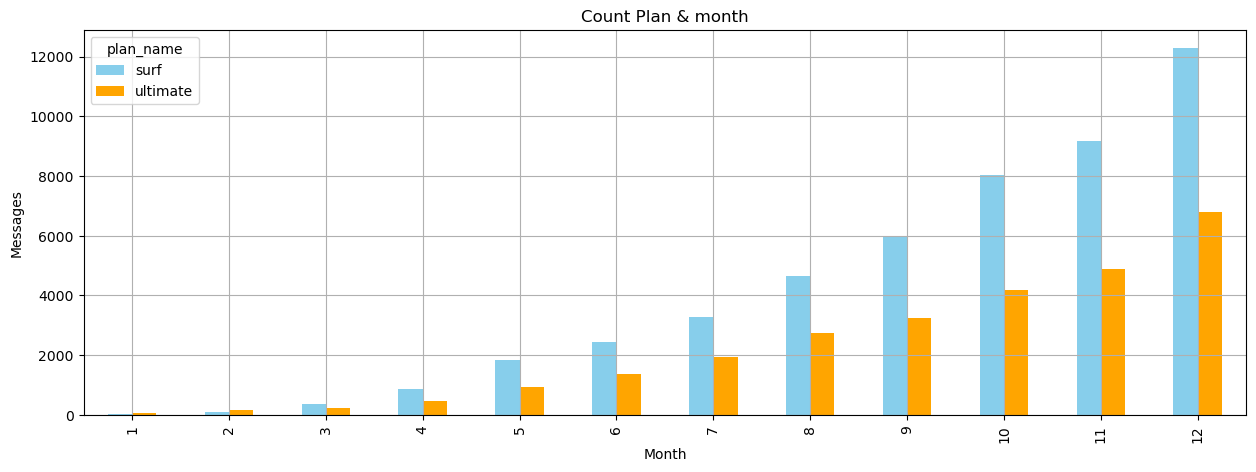

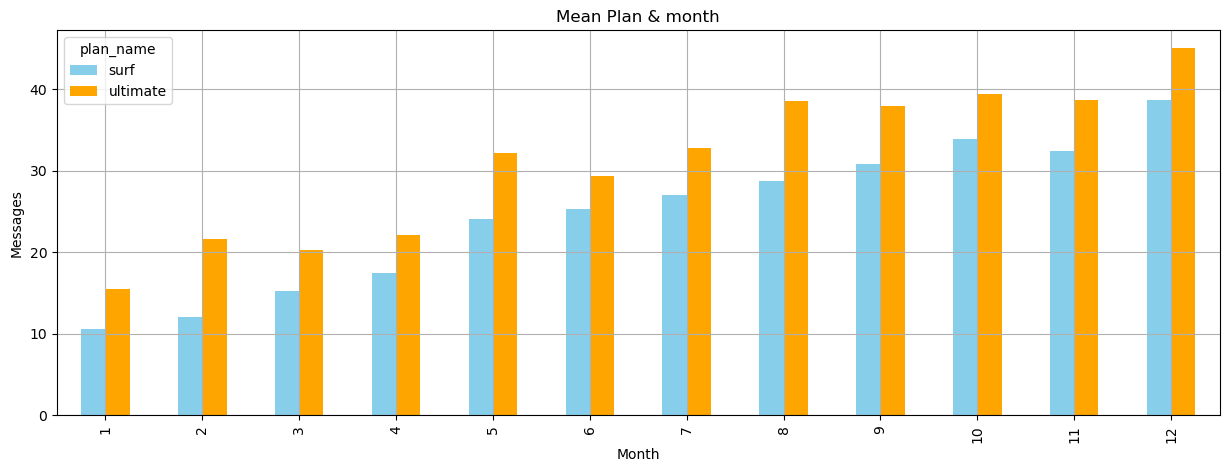

In [117]:
# Comparación de número de Mensajes
num_sms_plan_month.plot(xlabel = 'Month',
                        ylabel = 'Messages',
                        title = 'Count Plan & month',
                        kind = 'bar',
                        color = ['skyblue', 'orange'],
                        legend = 'Plan',
                        figsize = (15,5),
                        grid =True)
plt.show()
print('===================================================================')
# Comparación del promedio de Mensajes -> Gráfico
mean_sms_plan_month.plot(xlabel = 'Month',
                        ylabel = 'Messages',
                        title = 'Mean Plan & month',
                        kind = 'bar',
                        color = ['skyblue', 'orange'],
                        legend = 'Plan',
                        figsize = (15,5),
                        grid =True)
plt.show()

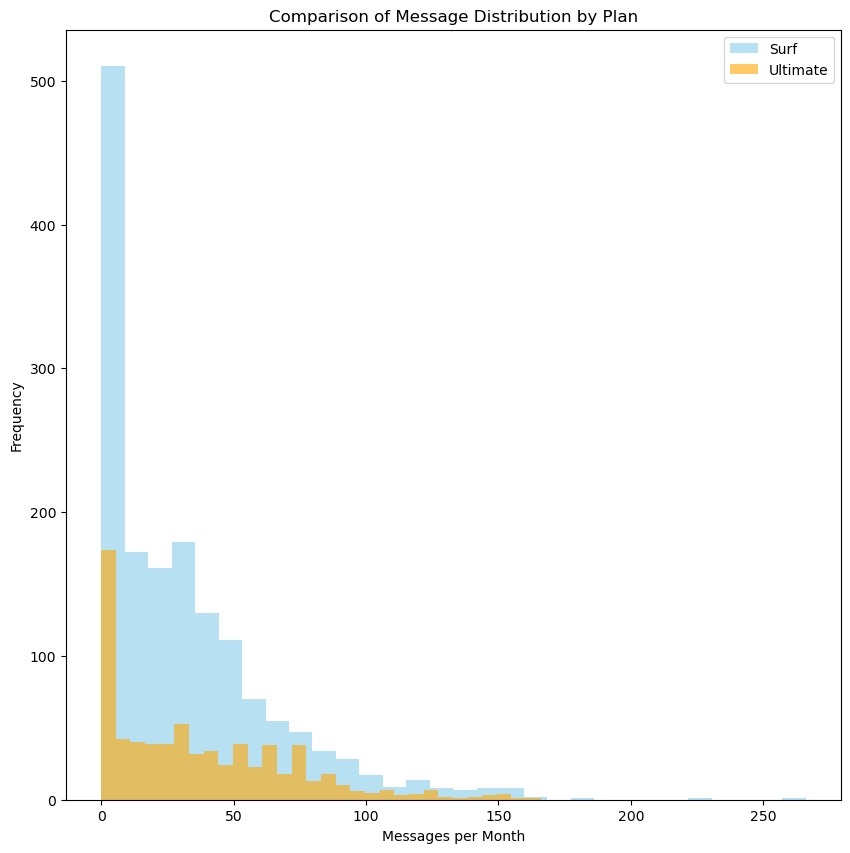

In [119]:
# Comparación del número de mensajes mensuales que necesitan los usuarios de cada plan.
surf_messages = df_total_fee[df_total_fee['plan_name'] == 'surf']['messages_count']
ultimate_messages = df_total_fee[df_total_fee['plan_name'] == 'ultimate']['messages_count']

# Juntar los DataFrame
surf_messages.plot(kind = 'hist',
                   bins = 30,
                   alpha = 0.6,
                   color = 'skyblue',
                   figsize = (10,10),
                   ylabel = 'Users',
                   title = 'Comparison of Message Distribution by Plan')
ultimate_messages.plot(kind = 'hist',
                      bins = 30,
                      alpha = 0.6,
                      color = 'orange')
plt.xlabel('Messages per Month')
plt.legend(['Surf','Ultimate'])
plt.show()

In [120]:
# Media y Varianza de la cantidad mensual de mensajes.

# Ya poseo los planes diferenciados (Surf & Ultimate) respecto a su cantidad de llamadas
# Surf -> Media y Varianza
media_surf_messages = surf_messages.mean().round(2)
var_surf_messages = surf_messages.var()
desv_surf_messages = np.sqrt(var_surf_messages).round(2)
print('Los datos del Plan Surf:')
print('-> Media:', media_surf_messages)
print('-> Varianza:', var_surf_messages)
print('-> Sigma:', desv_surf_messages)
print('===================================================================')
# Ultimate -> Media y Varianza
media_ultimate_messages = ultimate_messages.mean().round(2)
var_ultimate_messages = ultimate_messages.var()
desv_ultimate_messages = np.sqrt(var_ultimate_messages).round(2)
print('Los datos del Plan Ultimate:')
print('-> Media:', media_ultimate_messages)
print('-> Varianza:', var_ultimate_messages)
print('-> Sigma:', desv_ultimate_messages)


Los datos del Plan Surf:
-> Media: 31.16
-> Varianza: 1126.7245219504084
-> Sigma: 33.57
Los datos del Plan Ultimate:
-> Media: 37.55
-> Varianza: 1208.756743548134
-> Sigma: 34.77


C:\Users\ricar\AppData\Local\Temp\ipykernel_20344\1527581239.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot_messages,


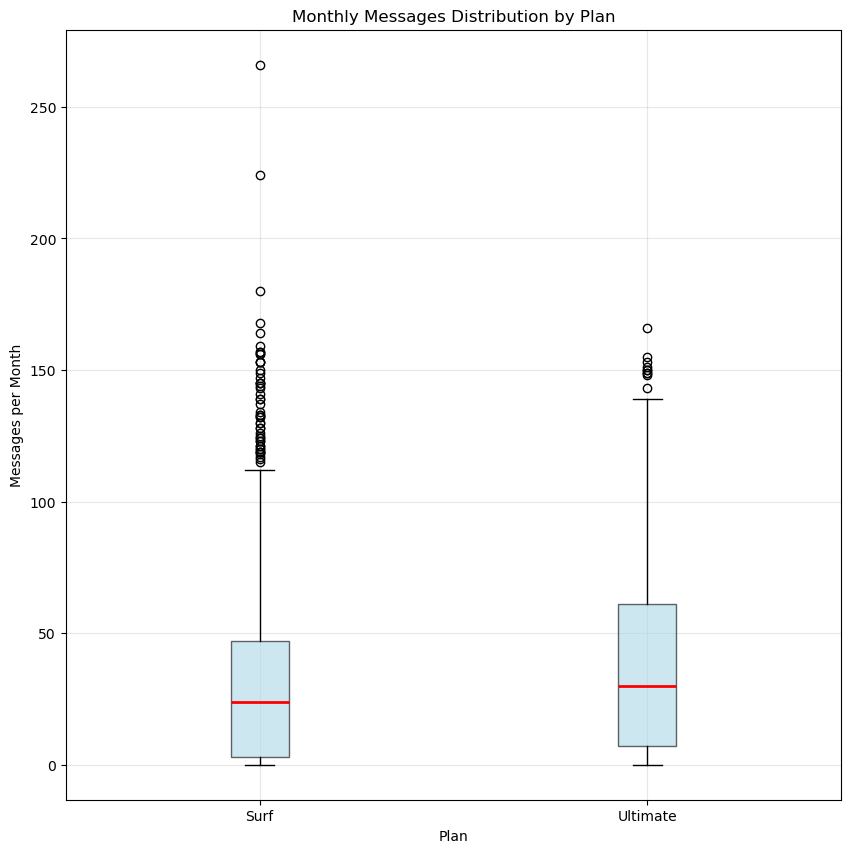

In [121]:
# Diagrama de caja para visualizar la distribución de la cantidad mensual de mensajes
surf_messages = df_total_fee[df_total_fee['plan_name'] == 'surf']['messages_count']
ultimate_messages = df_total_fee[df_total_fee['plan_name'] == 'ultimate']['messages_count']

data_to_plot_messages = [surf_messages, ultimate_messages]
plt.figure(figsize = (10,10))

# Creación del Diagrama de Caja
plt.boxplot(data_to_plot_messages, 
            labels = ['Surf', 'Ultimate'],
            patch_artist = True,
            boxprops = dict(facecolor = 'lightblue', alpha = 0.6),
            medianprops = dict(color = 'red', linewidth = 2))
plt.xlabel('Plan')
plt.ylabel('Messages per Month')
plt.title('Monthly Messages Distribution by Plan')
plt.grid(True, alpha = 0.3)
plt.show()

##### Comentario
En el gráfico de cantidad de mensajes por usuario y mes, podemos visualizar que existe un gran número de mensajes por parte de los clientes del plan 'Surf', siendo esto explicado por ser una mayor cantidad de clientes en comparación al plan 'Ultimate'. Sin embargo, si nos despalzamos al siguiente gráfico, en donde nos enfocamos en el número promedio de mensajes de texto por usuario y mes, hay una mayor cantidad de mensajes por usuario por parte del plan 'Ultimate'. Este comportamiento se puede ver como algo esperado, ya que dentro de las características del plan es tener una mayor cantidad de mensajes disponibles para su uso.
Si nos fijamos en el historigrama, los usuarios del plan 'Surf' tienen una tendencia a utilizar con poca frecuencia los mensajes de texto. Sin embargo, los usuarios del plan 'Ultimate' saben que tienen más mensajes para su uso y goce, llevando a que la distribución sea amplia.
Por otro lado, tenemos el Diagrama de caja, en donde nos enfocamos en el estudio de los datos estadísticos que presentan los usuarios de ambos planes de telecomunicaciones. Lo más destacable, es que existe una gran tendencia del útlimo cuartil (Q3), en donde tiene una banda de datos extendida en comparación a los otros cuartiles. Sin embargo, debemos considerar que hay más datos sesgados dentro de los datos de los usuarios del plan 'Surf', siendo estos claramente los usuarios que tuvieron que pagar extra por los mensajes enviados.

### Internet

In [122]:
# Comparación de la cantidad de tráfico de Internet consumido por usuarios por plan
print('===================================================================')
num_gb_plan_month = df_total_fee.groupby(['month_x','plan_name'])['gb_used'].sum().unstack()
print(num_gb_plan_month)
print('===================================================================')

# Comparación del promedio de tráfico de Internet consumido por usuarios por plan
mean_gb_plan_month = df_total_fee.groupby(['month_x','plan_name'])['gb_used'].mean().unstack()
print(mean_gb_plan_month.round(2))
print('===================================================================')

plan_name    surf  ultimate
month_x                    
1            10.0      29.0
2           114.0     123.0
3           317.0     226.0
4           621.0     346.0
5          1113.0     495.0
6          1528.0     744.0
7          2093.0     992.0
8          2795.0    1304.0
9          3311.0    1508.0
10         4207.0    1917.0
11         4764.0    2227.0
12         5917.0    2844.0
plan_name   surf  ultimate
month_x                   
1           5.00      7.25
2          12.67     17.57
3          13.78     18.83
4          12.42     16.48
5          14.45     17.07
6          15.75     15.83
7          17.30     16.81
8          17.25     18.37
9          17.07     17.53
10         17.75     18.08
11         16.83     17.54
12         18.61     18.83


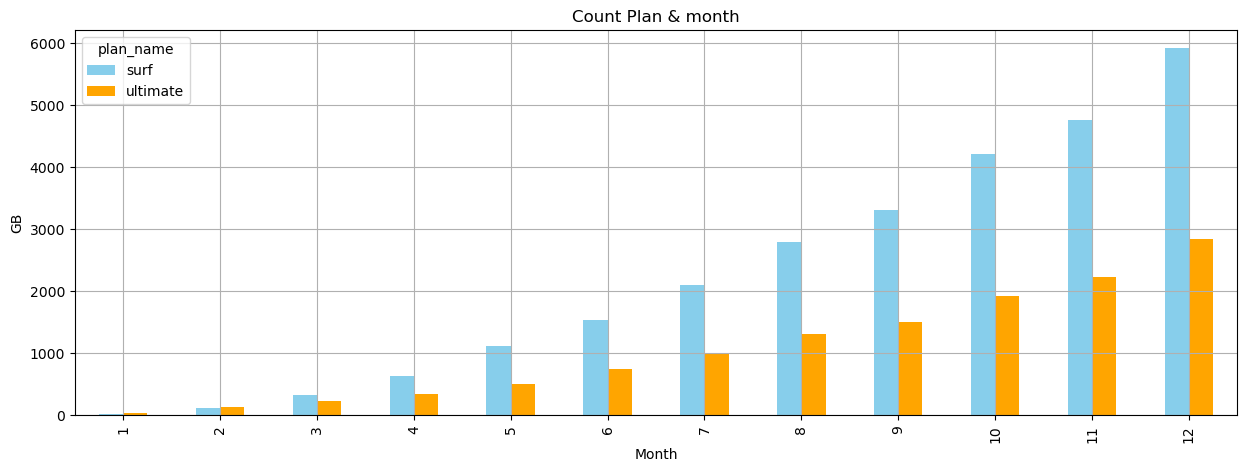

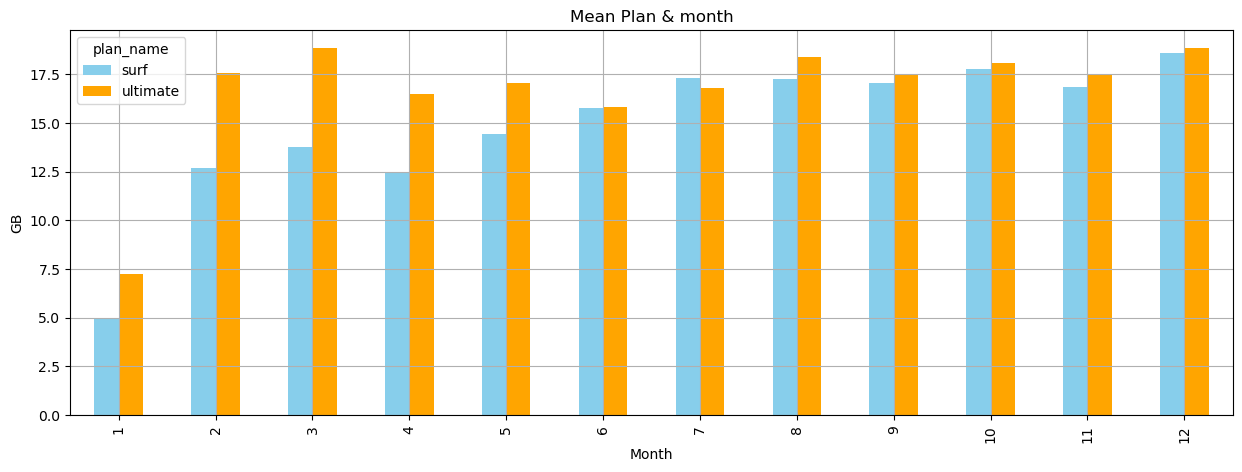

In [123]:
# Comparación de número de GB
num_gb_plan_month.plot(xlabel = 'Month',
                       ylabel = 'GB',
                       title = 'Count Plan & month',
                       kind = 'bar',
                       color = ['skyblue', 'orange'],
                       legend = 'Plan',
                       figsize = (15,5),
                       grid =True)
plt.show()
print('===================================================================')
# Comparación del promedio de GB
mean_gb_plan_month.plot(xlabel = 'Month',
                        ylabel = 'GB',
                        title = 'Mean Plan & month',
                        kind = 'bar',
                        color = ['skyblue', 'orange'],
                        legend = 'Plan',
                        figsize = (15,5),
                        grid =True)
plt.show()


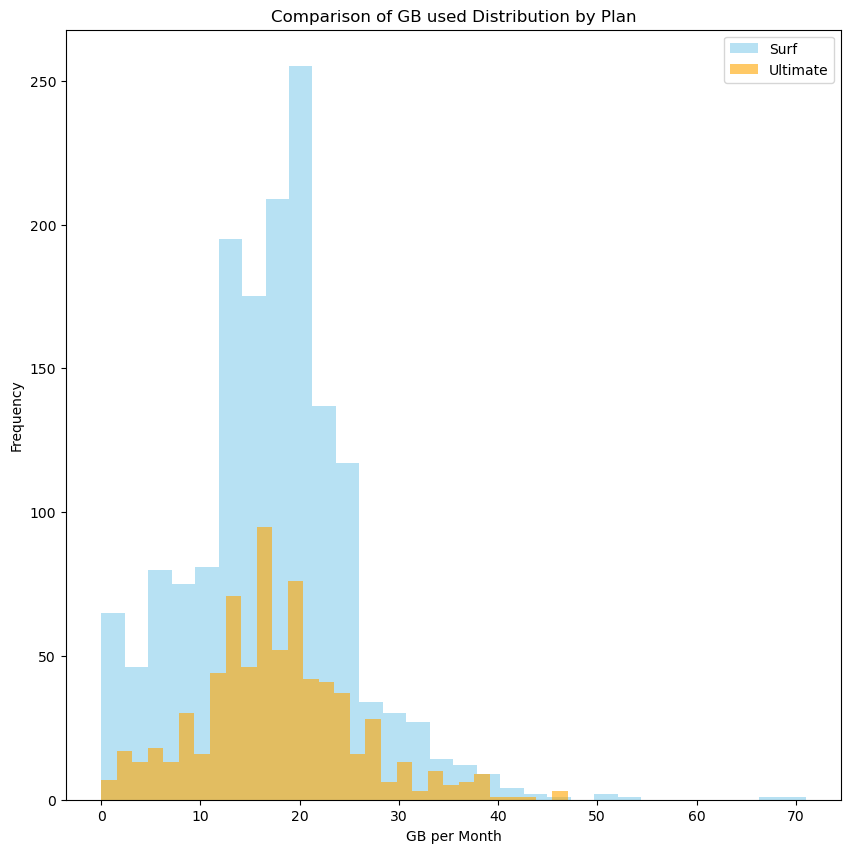

In [124]:
# Comparación del número de GB usados mensuales que necesitan los usuarios de cada plan. Traza un histograma.
surf_gb = df_total_fee[df_total_fee['plan_name'] == 'surf']['gb_used']
ultimate_gb = df_total_fee[df_total_fee['plan_name'] == 'ultimate']['gb_used']

# Juntar los DataFrame
surf_gb.plot(kind = 'hist',
             bins = 30,
             alpha = 0.6,
             color = 'skyblue',
             figsize = (10,10),
             ylabel = 'Users',
             title = 'Comparison of GB used Distribution by Plan')
ultimate_gb.plot(kind = 'hist',
                 bins = 30,
                 alpha = 0.6,
                 color = 'orange')
plt.xlabel('GB per Month')
plt.legend(['Surf','Ultimate'])
plt.show()

In [125]:
# Media y Varianza de la cantidad mensual de tráfico en internet en GB.

# Ya poseo los planes diferenciados (Surf & Ultimate) respecto a su cantidad de tráfico en internet en GB
# Surf -> Media y Varianza
media_surf_gb = surf_gb.mean().round(2)
var_surf_gb = surf_gb.var().round(2)
desv_surf_gb = np.sqrt(var_surf_gb).round(2)
print('Los datos del Plan Surf:')
print('-> Media:', media_surf_gb)
print('-> Varianza:', var_surf_gb)
print('-> Sigma:', desv_surf_gb)
print('===================================================================')
# Ultimate -> Media y Varianza
media_ultimate_gb = ultimate_gb.mean().round(2)
var_ultimate_gb = ultimate_gb.var().round(2)
desv_ultimate_gb = np.sqrt(var_ultimate_gb).round(2)
print('Los datos del Plan Ultimate:')
print('-> Media:', media_ultimate_gb)
print('-> Varianza:', var_ultimate_gb)
print('-> Sigma:', desv_ultimate_gb)

AttributeError: 'float' object has no attribute 'round'

C:\Users\ricar\AppData\Local\Temp\ipykernel_20344\2401397752.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot_gb,


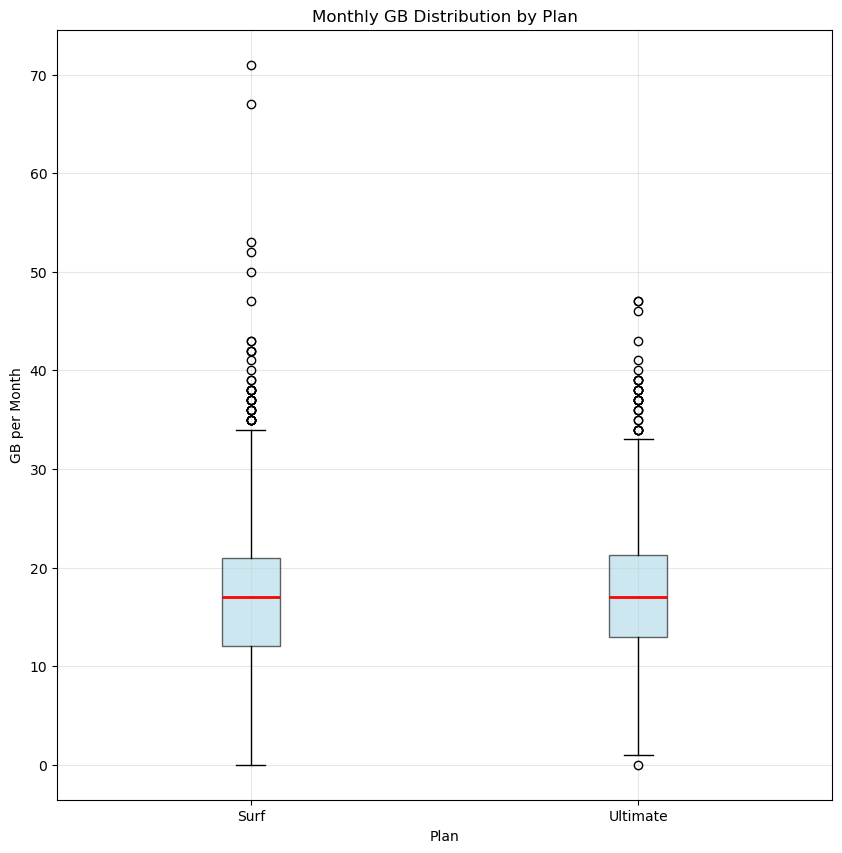

In [126]:
# Diagrama de caja para visualizar la distribución de la cantidad mensual de tráfico de internet en GB
surf_gb = df_total_fee[df_total_fee['plan_name'] == 'surf']['gb_used']
ultimate_gb = df_total_fee[df_total_fee['plan_name'] == 'ultimate']['gb_used']

data_to_plot_gb = [surf_gb, ultimate_gb]
plt.figure(figsize = (10,10))

# Creación del Diagrama de Caja
plt.boxplot(data_to_plot_gb, 
            labels = ['Surf', 'Ultimate'],
            patch_artist = True,
            boxprops = dict(facecolor = 'lightblue', alpha = 0.6),
            medianprops = dict(color = 'red', linewidth = 2))
plt.xlabel('Plan')
plt.ylabel('GB per Month')
plt.title('Monthly GB Distribution by Plan')
plt.grid(True, alpha = 0.3)
plt.show()

##### Comentario
Respecto al gráfico de la cantidad de GB por usuario y mes, existe una mayor cantidad de datos utilizados en el plan 'Surf', por la presencia de una mayor cantidad de usuarios, teniendo un comportamiento de crecimiento uniforme (una tendencia ascendente clara). Por otro lado, tenemos el gráfico del promedio de GB por usuario y mes, existe un mayor uso de GB por parte de los usuarios del plan 'Ultimate', ya que ellos tienen la disponibilidad de más datos móviles. Sin embargo, desde el 6to mes en adelante se puede apreciar un comportamiento similar entre los usuarios de ambos planes, mostrando que los usuarios tienen una tendencia al uso de los 15 GB (mostrando que existen usuarios que pagaron extra por datos móviles adicionales).
Respecto al historigrama, podemos extraer que los usuarios tienen una tendencia a consumir los 15 GB de datos de internet, lo que lleva que en ambos planes tienen un comportamiento de uso bastante parecido. Es llamatico que aún existen usuarios que consumen muchos clientes que pagan más por el uso de datos, siendo una oportunidad de negocio adicionando nuevos planes o ajustando el límite con el precio del plan 'Surf'.
Respecto al Diagrama de caja, podemos divisar que la forma del flujo es bastante uniforme en cuanto a la distancia entre los cuartiles. No obstante, en el plan 'Surf' existe una gran cantidad de datos que se encuentran fuera del alcance del último cuartil, llevando a que existam datos que puedan hacer ruido a nuestro análisis.

## Ingreso

In [127]:
# Comparación de la cantidad de ingresos mensuales que generan los usuarios por plan
sum_income_plan_month = df_total_fee.groupby(['month_x','plan_name'])['income_month_plan'].sum().unstack()
print(sum_income_plan_month.round(2))
print('===================================================================')

# Comparación el promedio de Income consumido por usuarios por plan
mean_income_plan_month = df_total_fee.groupby(['month_x','plan_name'])['income_month_plan'].mean().unstack()
print(mean_income_plan_month.round(2))

plan_name      surf  ultimate
month_x                      
1             40.00    280.00
2            325.17    490.00
3           1067.05    894.88
4           2044.33   1536.92
5           3742.17   2047.92
6           4782.60   3363.92
7           7729.16   4245.92
8          10509.65   5184.76
9          11419.87   6197.80
10         15578.43   7669.76
11         16718.41   9111.76
12         22617.94  11090.52
plan_name   surf  ultimate
month_x                   
1          20.00     70.00
2          36.13     70.00
3          46.39     74.57
4          40.89     73.19
5          48.60     70.62
6          49.31     71.57
7          63.88     71.96
8          64.87     73.02
9          58.87     72.07
10         65.73     72.36
11         59.08     71.75
12         71.13     73.45


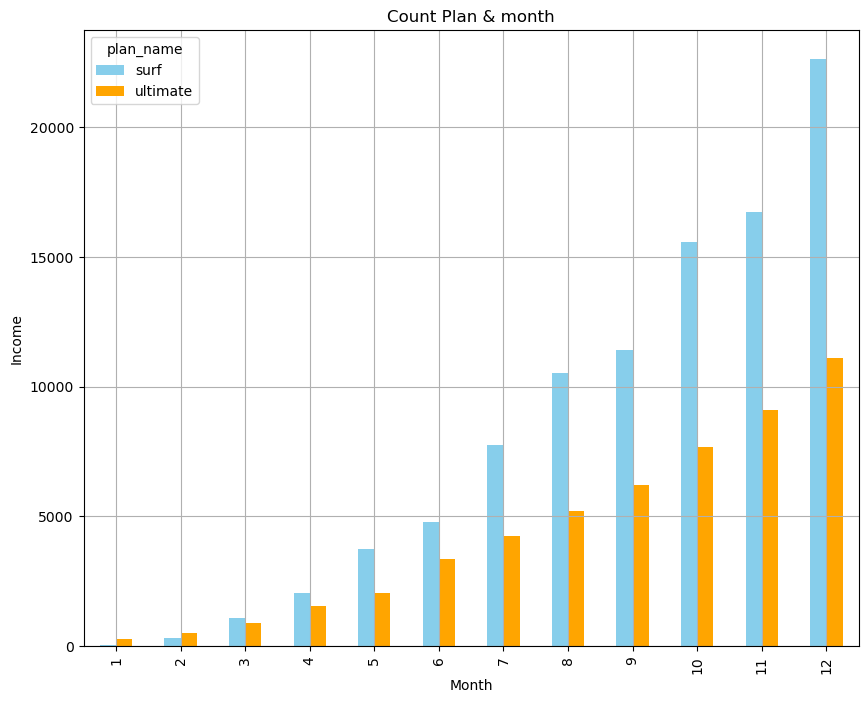

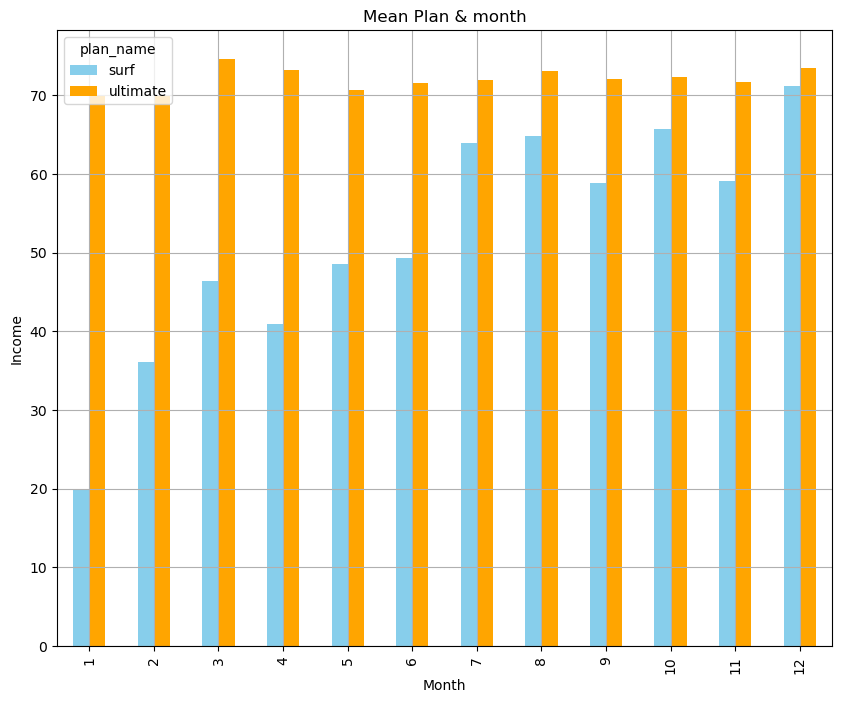

In [128]:
# Comparación de la cantidad de ingresos mensuales que generan los usuarios por plan
sum_income_plan_month.plot(xlabel = 'Month',
                           ylabel = 'Income',
                           title = 'Count Plan & month',
                           kind = 'bar',
                           color = ['skyblue', 'orange'],
                           legend = 'Plan',
                           figsize = (10,8),
                           grid =True)
plt.show()
print('===================================================================')
# Comparación del promedio de la cantidad de ingresos mensuales que generan los usuarios por plan
mean_income_plan_month.plot(xlabel = 'Month',
                            ylabel = 'Income',
                            title = 'Mean Plan & month',
                            kind = 'bar',
                            color = ['skyblue', 'orange'],
                            legend = 'Plan',
                            figsize = (10,8),
                            grid =True)
plt.show()

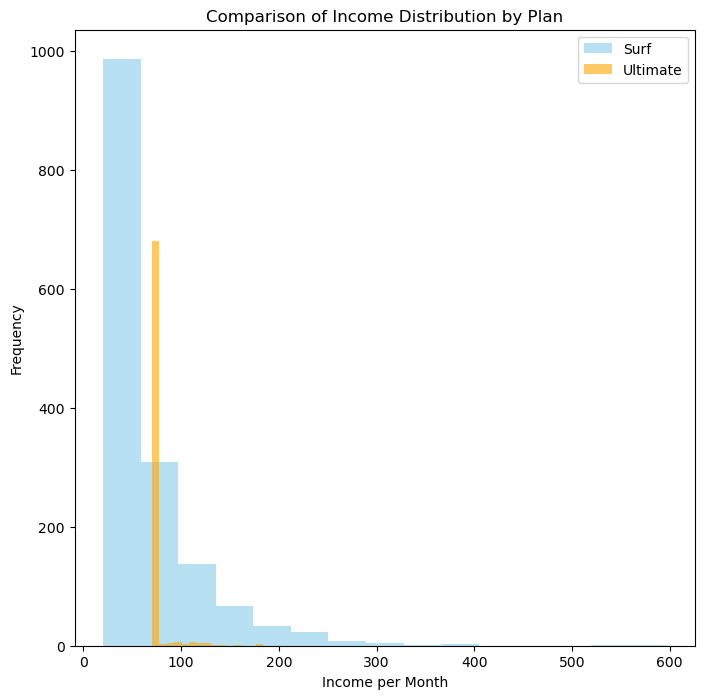

In [129]:
# Comparación de la cantidad de ingresos usados mensuales que necesitan los usuarios de cada plan.
surf_income = df_total_fee[df_total_fee['plan_name'] == 'surf']['income_month_plan']
ultimate_income = df_total_fee[df_total_fee['plan_name'] == 'ultimate']['income_month_plan']

# Juntar los DataFrame
surf_income.plot(kind = 'hist',
                 bins = 15,
                 alpha = 0.6,
                 color = 'skyblue',
                 figsize = (8,8),
                 ylabel = 'Users',
                 title = 'Comparison of Income Distribution by Plan')
ultimate_income.plot(kind = 'hist',
                     bins = 15,
                     alpha = 0.6,
                     color = 'orange')
plt.xlabel('Income per Month')
plt.legend(['Surf','Ultimate'])
plt.show()

In [133]:
# Media y Varianza de la cantidad mensual de ingresos

# Ya poseo los planes diferenciados (Surf & Ultimate) respecto a sus Ingresos
# Surf -> Media y Varianza
media_surf_income = surf_income.mean().round(2)
var_surf_income = surf_income.var()
desv_surf_income = np.sqrt(var_surf_income).round(2)
print('Los datos del Plan Surf:')
print('-> Media:', media_surf_income)
print('-> Varianza:', var_surf_income)
print('-> Sigma:', desv_surf_income)
print('===================================================================')
# Ultimate -> Media y Varianza
media_ultimate_income = ultimate_income.mean().round(2)
var_ultimate_income = ultimate_income.var()
desv_ultimate_income = np.sqrt(var_ultimate_income).round(2)
print('Los datos del Plan Ultimate:')
print('-> Media:', media_ultimate_income)
print('-> Varianza:', var_ultimate_income)
print('-> Sigma:', desv_ultimate_income)

Los datos del Plan Surf:
-> Media: 61.4
-> Varianza: 3178.2652538162306
-> Sigma: 56.38
Los datos del Plan Ultimate:
-> Media: 72.38
-> Varianza: 136.58937352495528
-> Sigma: 11.69


C:\Users\ricar\AppData\Local\Temp\ipykernel_20344\2805797841.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot_income,


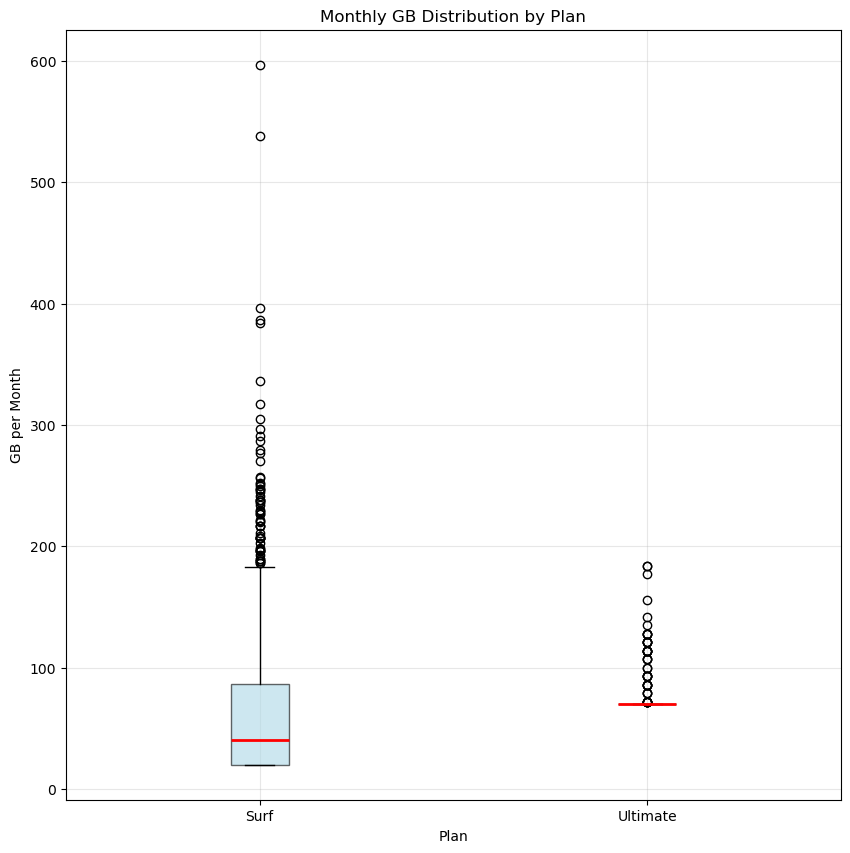

In [134]:
# Diagrama de caja para visualizar la distribución de los Ingresos Mensuales que generan los usuarios por plan
surf_income = df_total_fee[df_total_fee['plan_name'] == 'surf']['income_month_plan']
ultimate_income = df_total_fee[df_total_fee['plan_name'] == 'ultimate']['income_month_plan']

data_to_plot_income = [surf_income, ultimate_income]
plt.figure(figsize = (10,10))

# Creación del Diagrama de Caja
plt.boxplot(data_to_plot_income, 
            labels = ['Surf', 'Ultimate'],
            patch_artist = True,
            boxprops = dict(facecolor = 'lightblue', alpha = 0.6),
            medianprops = dict(color = 'red', linewidth = 2))
plt.xlabel('Plan')
plt.ylabel('GB per Month')
plt.title('Monthly GB Distribution by Plan')
plt.grid(True, alpha = 0.3)
plt.show()

##### Comentario
Para ir a lo más destacable, en el gráfico del ingreso promedio por usuarios y mes hay una estabilidad de ingresos por usuarios en el plan 'Ultimate', siendo cercano a los 70 dólares (cercano al valor original del plan). Sin embargo, si nos enfocamos en los ingresos del plan 'Surf', tiene una tendencia al alza, ya que los usuarios tienden a pagar por minutos, mensajes o gigas extra y satisfacer sus necesidades de conexión con el resto del mundo.
Respecto al historigrama, lo más destacable es que los usuarios del plan 'Surf' tienen demasiados gastos por los servicios de Megaline, siendo rentable para la empresa de telecomuniaciones. Sin embargo, debemos tener en consideración este tipo de comportamiento, ya que si una empresa competidora y muestre interés por este tipo de target, podría tener Megaline un éxodo de clientes, siendo una amenaza.
Por otro lado, en cuanto a los datos que pudimos recabar, en cuanto a la varianza y desviación estándar de los ingresos por parte de los usuarios del plan 'Surf', hay una amplia distribución de datos, siendo bastante llamativo y debemos considerar al momento de analizar la información recopilada.
En cuanto al Diagrama de caja, podemos ver que en el plan 'Ultimate', los datos de los cuartiles s ecentran dentro del mimso parámetro de ingresos, cercano a los 70 dólares. Por otro lado, tenemos que en el otro plan hay una distribución bastante extensa, siendo en muchos casos, usuarios que pagan más que el plan más caro.

## Prueba las hipótesis estadísticas

En cuanto a la Prueba de hipótesis, vamos a determinar si los ingresos mensuales promedio de los planes 'Surf' y 'Ultimate' tienen un comportamiento similar.
La hipótesis nula es que los datos e información de los usuarios de ambos planes tienen un comportamiento igual (=) y la hipótesis alternativa es que los usuarios de ambos planes tienen un compotamiento distinto. Vamos a considerar una distribución de dos colas, ya que nos enfocamos en verificar la similitud de información, no si es más o menos que un determinado ítem.
Para el ejercicio, consideramos Alpha = 0.05

In [138]:
# Prueba las hipótesis

# Número total de mnsualidades pagadas
total_monthly_payments = df_total_fee['user_id'].count()

# Número total de mensualidades pagadas por plan
monthly_surf = df_total_user[df_total_user['plan_name'] == 'surf']['user_id'].count()
monthly_ultimate = df_total_user[df_total_user['plan_name'] == 'ultimate']['user_id'].count()

# Ingresos por plan
income_surf = df_total_fee[df_total_fee['plan_name'] == 'surf']['income_month_plan']
income_ultimate = df_total_fee[df_total_fee['plan_name'] == 'ultimate']['income_month_plan']

# Medias de los planes
media_surf = sum_income_plan_month['surf'].sum() / monthly_surf
media_ultimate = sum_income_plan_month['ultimate'].sum() / monthly_ultimate

# Varianzas de los planes
var_surf = income_surf.var()
var_ultimate = income_ultimate.var()

# Desviación Estándar de los planes
std_surf = income_surf.std()
std_ultimate = income_ultimate.std()

print('Información: Surf')
print('-> Media:', media_surf.round(2))
print('-> Varianza:', var_surf)
print('-> Desv. Estándar:', std_surf)
print('-------------------------------------------------------------------')
print('Información: Ultimate')
print('-> Media:', media_ultimate.round(2))
print('-> Varianza:', var_ultimate)
print('-> Desv. Estándar:', std_ultimate)

print('===================================================================')
results = st.ttest_ind(income_surf, income_ultimate)
alpha = 0.05
print('valor p:', results.pvalue / 2)
if results.pvalue / 2 < alpha:
    print('Rechazamos la hipótesis nula')
else:
    print('No podemos rechazar la hipótesis nula')
print('===================================================================')

Información: Surf
-> Media: 61.4
-> Varianza: 3178.2652538162306
-> Desv. Estándar: 56.37610534451835
-------------------------------------------------------------------
Información: Ultimate
-> Media: 72.38
-> Varianza: 136.58937352495528
-> Desv. Estándar: 11.687145653450003
valor p: 1.2229501693286912e-07
Rechazamos la hipótesis nula


En cuanto a la Prueba de hipótesis de este punto, vamos a determinar si los ingresos mensuales promedio de los planes 'Surf' y 'Ultimate' (en conjunto) que son de Nueva York - Nueva Jersey, tienen un comportamiento similar a los que pertenecen a otras áreas de USA.
La hipótesis nula es que los datos e información de los usuarios de ambos planes y son de NY - NJ tienen un comportamiento igual (=)a las de otras regiones de USA; y la hipótesis alternativa es que los usuarios de ambos planes y son de NY - NJ tienen un compotamiento distinto a las de otras regiones de USA.
Vamos a considerar una distribución de dos colas, ya que nos enfocamos en verificar la similitud de información, no si es más o menos que un determinado ítem.
Para el ejercicio, consideramos Alpha = 0.05

In [140]:
# Prueba las hipótesis

# Verifiquemos las ciudades con sus códigos
print(df_total_fee['city'].unique())
print('===================================================================')
# Función para identificar si una ciudad pertenece al área NY-NJ
def is_ny_nj_area(city):
    # Busca palabras clave que indiquen área NY-NJ
    # keyword te permite buscar los carácteres solicitados en 'ny_nj_keywords'
    ny_nj_keywords = ['New York', 'Newark', 'Jersey City', 'NY-NJ']
    return any(keyword in city for keyword in ny_nj_keywords)

# Aplicar la función para crear una nueva columna
    # Lambda es una herramienta temporal y compacta
df_total_fee['region'] = df_total_fee['city'].apply(
    lambda x: 'NY-NJ' if is_ny_nj_area(x) else 'Other'
)

# Verificar cuántos usuarios hay en cada región
print('Distribución por región:')
print(df_total_fee['region'].value_counts())
print('===================================================================')

# Ver algunas ciudades clasificadas como NY-NJ
print('Ciudades clasificadas como NY-NJ:')
ny_nj_cities = df_total_fee[df_total_fee['region'] == 'NY-NJ']['city'].unique()
print(ny_nj_cities)

print('===================================================================')
# Separar ingresos por región para la prueba de hipótesis
income_ny_nj = df_total_fee[df_total_fee['region'] == 'NY-NJ']['income_month_plan']
income_others = df_total_fee[df_total_fee['region'] == 'Other']['income_month_plan']

print(f'Usuarios NY-NJ: {len(income_ny_nj)}')
print(f'Usuarios otras regiones: {len(income_others)}')

print('===================================================================')
# Información de NY - NJ
mean_ny_nj = df_total_fee[df_total_fee['region'] == 'NY-NJ']['income_month_plan'].mean()
var_ny_nj = df_total_fee[df_total_fee['region'] == 'NY-NJ']['income_month_plan'].var()
std_ny_nj = df_total_fee[df_total_fee['region'] == 'NY-NJ']['income_month_plan'].std()

print('Información: NY - NJ')
print('-> Media:', mean_ny_nj)
print('-> Varianza:', var_ny_nj)
print('-> Desv. Estándar:', std_ny_nj)
print('-------------------------------------------------------------------')
# Información de Otras regiones
mean_others = df_total_fee[df_total_fee['region'] == 'Other']['income_month_plan'].mean()
var_others = df_total_fee[df_total_fee['region'] == 'Other']['income_month_plan'].var()
std_others = df_total_fee[df_total_fee['region'] == 'Other']['income_month_plan'].std()

print('Información: Others')
print('-> Media:', mean_others.round(2))
print('-> Varianza:', var_others)
print('-> Desv. Estándar:', std_others)

print('===================================================================')
results = st.ttest_ind(income_ny_nj, income_others)
print('valor p:', results.pvalue / 2)
if (results.pvalue / 2) < alpha / 2:
    print('Rechazamos la hipótesis nula')
else:
    print('No podemos rechazar la hipótesis nula')
print('===================================================================')

['Atlanta-Sandy Springs-Roswell, GA MSA' 'Seattle-Tacoma-Bellevue, WA MSA'
 'Las Vegas-Henderson-Paradise, NV MSA' 'Tulsa, OK MSA'
 'Dallas-Fort Worth-Arlington, TX MSA'
 'San Francisco-Oakland-Berkeley, CA MSA' 'Grand Rapids-Kentwood, MI MSA'
 'Orlando-Kissimmee-Sanford, FL MSA'
 'San Jose-Sunnyvale-Santa Clara, CA MSA' 'Cleveland-Elyria, OH MSA'
 'Chicago-Naperville-Elgin, IL-IN-WI MSA' 'Knoxville, TN MSA'
 'New York-Newark-Jersey City, NY-NJ-PA MSA' 'Pittsburgh, PA MSA'
 'Fresno, CA MSA' 'Washington-Arlington-Alexandria, DC-VA-MD-WV MSA'
 'Indianapolis-Carmel-Anderson, IN MSA' 'Jacksonville, FL MSA'
 'Los Angeles-Long Beach-Anaheim, CA MSA'
 'Omaha-Council Bluffs, NE-IA MSA'
 'Houston-The Woodlands-Sugar Land, TX MSA'
 'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA'
 'Tampa-St. Petersburg-Clearwater, FL MSA' 'Birmingham-Hoover, AL MSA'
 'Oklahoma City, OK MSA' 'Charlotte-Concord-Gastonia, NC-SC MSA'
 'Denver-Aurora-Lakewood, CO MSA'
 'Nashville-Davidson–Murfreesboro–Franklin, TN M

## Conclusión general 
De modo de conclusión, podemos destacar lo siguiente:
* Los DataFrame al momento de leerlos, siempre tenemos que tener cuidado al momento de cargarlos en nuestro Notebook, ya que podemos tener problemas de análisis. Además, es necesario identificar anomalías (datos duplicados y/o erróneos) y corregirlos, y en este caso, enriquecer los datos para hacer evaluaciones eficientes.
* El uso de métodos para unir DataFrame, en especial la función merge(), nos ayudan a cruzar la información y poder analizar correctamente la información, y esta es la finalidad del buen uso de esta herramienta.
En cuanto al estudio de los DataFrame, podemos determinar que:
* Las llamadas de los clientes fue bastante similar entre ambos planes, siendo semejante su duración promedio. Este es un punto a considerar, ya que los clientes del plan 'Surf' tienen minutos limitados de 500. Sin embargo, la gran mayoría de usuarios no consumió más del límite establecido.
* Los mensajes de texto están dentro de los parámetros establecidos por los planes contratados por los usuarios, ya que el consumo se encuentra dentro de los parámetros y muy pocos clientes han pagado extra por este tipo de servicio de mensajería.
* El tráfico de internet (GB) los clientes han mostrado un comportamiento similar, en ambos tipos de planes, siendo cercano al consumo de los 15 GB. Sin embargo, esto nos demuestra que los usuarios del plan 'Surf' están consumiendo GB extras, haciendo que paguen montos adicionales. Este es un indicio para que la empresa evalúe en la creación de un nuevo plan, para una mayor captación de clientes o ajustar el precio y límites del plan 'Surf'.
* Los ingresos han mostrado una gran inclinación de recaudación de dinero por parte del plan 'Surf', ya que existe un gran consumo de servicios extra (en especial de GB). No obstante, debemos tener en consideración que podría ser una amenaza, ya que nuestros competidores pueden captar y satisfacer las necesidades de los clientes que pagan más por servicios adicionales. Es necesario tomar medidas para no tener una fuga de clientes.
* En cuanto a las pruebas de hiótesis realizadas, debemos determinar que los clientes de los planes 'Surf' y 'Ultimate', en cuanto a los ingresos percibidos mensualmente por usuario, no tienen el mismo comportamiento, ya que existe una gran volatilidad de ingresos por parte del plan más asequible. Por otro lado, tenemos que si lo vemos por los clientes que son de las áreas de Nueva York - Nueva Jersey en comparación a las otras regiones, nuevamente considerando el factor ingreso mensual por usuario, tienen un comportamiento que tienen una tendencia parecida y está dentro de los parámetros estadísticos, llevando a que se no se rechace la Hipótesis nula, es decir, son de comportamientos semejantes.
He aprendido que el comportamiento de los clientes puede variar por las necesidades y qué tan dispuestos están para cubrirlas, ya que existe un gran número de clientes que pagan más por su satisfacción. Para ello, es necesario realizar análisis exhaustivos de cada punto del negocio de la empresa, cómo repercute en la sociedad y qué beneficios trae consigo. Además, es necesario marcar una diferencia en comparación a la competencia y no estar bajo amenaza. Por lo tanto, estar actualizando información, analizarla y tomar decisiones de forma oportuna para el éxito.